In [39]:
XLA_PYTHON_CLIENT_MEM_FRACTION=.5


import jax.numpy as jnp

import scipy.io as sio
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.sparse.linalg import eigsh
#%matplotlib inline
#import utils

if False:
    struc=np.load('dicarlo_data.npz')

    XT0=struc['XT0']
    XT1=struc['XT1']
    X40=struc['X40']
    X41=struc['X41']


    XT0=XT0-np.mean(XT0,axis=0)
    XT1=XT1-np.mean(XT1,axis=0)

    XT0=XT0-np.mean(XT0,axis=1)[:,None]
    XT1=XT1-np.mean(XT1,axis=1)[:,None]


    #print(np.shape(XT0))
    sresp=[XT0,XT1]

    plt.imshow(XT1[:200,:])


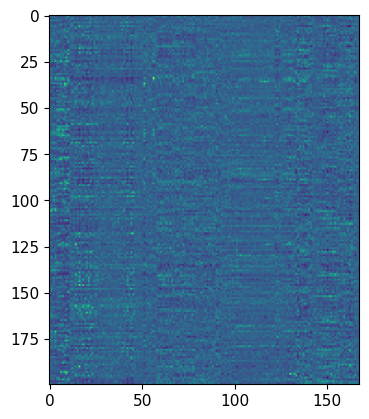

In [74]:
struc=np.load('dicarlo_data2.npz')

#X=struc['V4data']
X=struc['ITdata']

#M=V4data

X=X-np.mean(X,axis=0)[None,:]

X=X-np.mean(X,axis=1)[:,None]


#print(np.shape(XT0))
sresp=[X,X]

plt.imshow(X[:200,:])

In [75]:


def getKsTerms(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    Pr=P/M
    Qr=Q/F
    
    #if False:
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    denom =  (nTrKs_min2 +v)
    numer =  (nsTrKs +v)
    # There are some scaling differences, but all that matters is numer/denom, which cancels out the scaling factors.
    
    gammas=nsTrKs/nTrKs_min2
    gamma_mp1=gammas*P/(P-gammas)
    gamma_mp2=gammas*Q/(Q-gammas)
    
    return numer , denom , gammas, gamma_mp1,gamma_mp2

def getKong(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Kc = jnp.matmul(Xs1,Xs2.T)/Q

    #Knan = jnp.where(jnp.eye(P),jnp.nan,Kc)
    #KongEst = jnp.nanmean(jnp.square(Knan))
    KongEst = 2*jnp.trace(jnp.matmul(np.triu(Kc, 1),Kc))/(P*(P-1))
    return KongEst

def getKsTerms2(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    denom=getKong(Xs1,Xs2)*(P-1)/P
    
    numer=jnp.square(jnp.mean(Xs1*Xs2))
    
    return numer, denom
    
def getBias(x,y):
    #x/y
    #y_mean=np.mean(y)
    #y_var=np.square(np.std(y))

    x_mean=np.mean(x)
    y_mean=np.mean(y)
    y_var=np.square(np.std(y))/(np.shape(x)[0])

    xy_cov=np.mean((x-x_mean)*(y-y_mean))/(np.shape(x)[0])
    #xy_cov=np.cov(x,y)[0][1]
    
    bias = (x_mean/(y_mean**3))*y_var-1/np.square(y_mean)*xy_cov
    #bias_sample_corrected = bias/(np.shape(x)[0])
    
    return bias

def plotER(ax,xoi,qoi,cv='k',lv=''):
    yval=np.mean(qoi,axis=1)
    lower_error=np.quantile(qoi,axis=1,q=0.25)
    upper_error=np.quantile(qoi,axis=1,q=0.75)
    asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
    ax.errorbar(xoi, yval, yerr=asymmetric_error,c=cv,marker='o',ls='-',ms=3,label=lv)#, fmt='o')


def re(x):
    xv=np.array(x)
    return np.where(xv>0,xv,0)


def cal_gauss_est(Phi1,Phi2):
    NT=jnp.shape(Phi1)[0]
    N=jnp.shape(Phi1)[1]
    #NT=10000
    #N=10000
    c_hat = 1/NT*jnp.matmul(Phi1.T,Phi2) #normalized and shifted:
    #c_hat=jnp.cov(Phi.T)
    
    #N = c_hat.shape[0]  # Assuming c_hat is a square matrix
    #NT = N  # Adjust this if NT differs from N

    # Calculate \overline{a}
    a_bar = jnp.trace(c_hat) / N

    # Calculate \overline{c}
    sum_c = jnp.sum(c_hat) - jnp.trace(c_hat)
    c_bar = sum_c / (N * (N - 1))

    # Calculate \delta\hat{a}^2
    delta_a_squared = jnp.sum((jnp.diagonal(c_hat) - a_bar) ** 2) / (N - 1)

    # Calculate \delta\hat{c}^2
    #c_no_diag = c_hat.copy()
    #np.fill_diagonal(c_no_diag, 0)
    c_hat_cen=c_hat-c_bar
    #jnp.fill_diagonal(c_hat_cen, 0)
    c_hat_cen=jnp.where(1==jnp.eye(jnp.shape(c_hat)[0]),0,c_hat_cen)

    delta_c_squared = jnp.sum(c_hat_cen ** 2) / (N * (N - 1) - 2)

    # Calculate C2
    C2 = ((NT - 1) / NT) * delta_c_squared - ((a_bar ** 2 - c_bar ** 2) / NT) - \
         (4 / (N + 1)) * ((c_bar ** 2 - a_bar * c_bar) / NT)

    # Calculate A2
    A2 = ((NT - 1) / (NT + 1)) * delta_a_squared - \
         2 * ((a_bar ** 2 - c_bar ** 2) / (NT + 1)) + \
         (2 * delta_c_squared / (NT + 1))

    numer = N*a_bar**2
    denom = (a_bar**2 + A2) + (N-1) * (c_bar**2 + C2)
    #return a_bar, c_bar, delta_a_squared, delta_c_squared, C2, A2
    return numer, denom




In [76]:
numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(sresp[0],sresp[1],M=jnp.inf,F=jnp.inf)

GTv=numer/denom
print(gammas)

print(numer/denom)

F=np.shape(sresp[1])[1]
numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(sresp[0],sresp[1],M=jnp.inf,F=F)

#print(gammas)

print(numer/denom)

numer , denom = getKsTerms2(sresp[0],sresp[1])

print(numer/denom)



19.751251
23.890924
19.887613
19.894884


In [68]:
from jax import random


key = random.PRNGKey(0)

M=np.shape(sresp[0])[0]
F=np.shape(sresp[0])[1]

Ps=np.power(10,np.linspace(np.log10(5),np.log10(M),10)).astype(int)
#Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
Q=F#2000

key_A, key = random.split(key)
random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)# * sigma

numit=10
N=10
GTR=[]
GTR2=[]
GTR3=[]
GT=[]
GS=[]
GOS=[]
GOS2=[]
GOS3=[]
GOS4=[]
for i,P in enumerate(Ps):
    print('\r{:.2f}'.format(i/np.shape(Ps)[0]),end='')
    if P==M:
        Theta1=sresp[0][:,random_indicesQ]
        Theta2=sresp[1][:,random_indicesQ]
        
        numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.inf)
        GTR.append(numer/denom)
        GT.append(numer/denom)
        GS.append(gammas)
        GOS.append(numer/denom)
        
        numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=Q)
        GTR2.append(numer/denom)           
        GOS2.append(numer/denom)
        
        numer , denom = getKsTerms2(Theta1,Theta2)            
        GTR3.append(numer/denom)           
        GOS3.append(numer/denom)

        numer, denom = cal_gauss_est(Theta1,Theta1)
        GOS4.append(numer/denom)
        continue
        
    gts=[]
    gvs=[]
    grs=[]
    grs2=[]
    grs3=[]

    nums=[]
    dens=[]
    nums2=[]
    dens2=[]
    nums3=[]
    dens3=[]
    nums4=[]
    dens4=[]
    for k in range(numit):
        numers=[]
        denoms=[]
        numers2=[]
        denoms2=[]
        numers3=[]
        denoms3=[]
        numers4=[]
        denoms4=[]
        gss=[]
        for j in range(N):

            key_A, key = random.split(key)
            random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
            Theta1=sresp[0][random_indicesP,:][:,random_indicesQ]
            Theta2=sresp[1][random_indicesP,:][:,random_indicesQ] 

            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.inf)
            #numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.shape(Theta1)[1])
            
            numers.append(numer)
            denoms.append(denom)
            gss.append(gammas)
            
            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=Q)
            numers2.append(numer)
            denoms2.append(denom)            
            
            numer , denom = getKsTerms2(Theta1,Theta2)            
            numers3.append(numer)
            denoms3.append(denom)

            numer, denom = cal_gauss_est(Theta1,Theta1)
            numers4.append(numer)
            denoms4.append(denom)
            
        numers=np.array(numers)
        denoms=np.array(denoms)
        gamp=np.mean(numers)/np.mean(denoms)
        bias=getBias(numers,denoms)
        grs.append(gamp)
        gts.append(gamp-bias)
        gvs.append(np.mean(gss))
        nums.append(numers)
        dens.append(denoms)
        
        gamp2=np.mean(numers2)/np.mean(denoms2)
        gamp3=np.mean(numers3)/np.mean(denoms3)
        
        grs2.append(gamp2)
        grs3.append(gamp3)
        
        nums2.append(numers2)
        dens2.append(denoms2)
        nums3.append(numers3)
        dens3.append(denoms3)
        nums4.append(numers4)
        dens4.append(denoms4)
        
    GTR.append(np.array(grs))
    GTR2.append(np.array(grs2))
    GTR3.append(np.array(grs3))

    GT.append(np.array(gts))
    GS.append(np.array(gvs))
    GOS.append(np.concatenate(nums)/np.concatenate(dens))
    GOS2.append(np.concatenate(nums2)/np.concatenate(dens2))
    GOS3.append(np.concatenate(nums3)/np.concatenate(dens3))
    GOS4.append(np.concatenate(nums4)/np.concatenate(dens4))



0.90

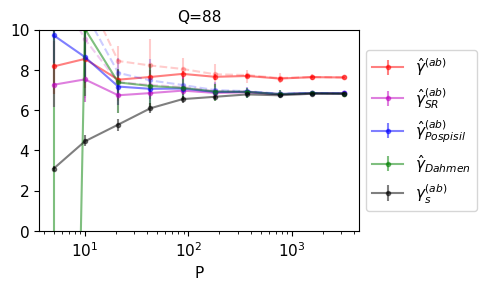

In [70]:

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(5,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=Ps
qoi=GTR

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


xoi=Ps
qoi=GTR2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

xoi=Ps
qoi=GTR3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')


xoi=Ps
qoi=GOS

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS4

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='g',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}_{Dahmen}$')#, fmt='o')




xoi=Ps
qoi=GS
yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

#ax.hlines(GT,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

ax.set_xlabel('P')
ax.legend(fontsize=11)

ax.set_title('Q={}'.format(Q),fontsize=11)
ax.set_ylim([0,10])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()

#fig.savefig('St_vary_P_fix_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
ax.set_xscale('log')

#fig.savefig('St_vary_P_fix_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")


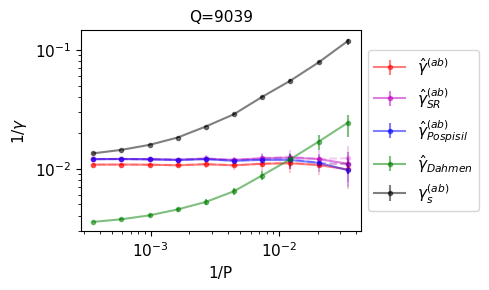

In [25]:
def getre(x):
    return [1/xv for xv in x]
    

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(5,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=1/Ps
qoi=getre(GTR)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


xoi=1/Ps
qoi=getre(GTR2)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

xoi=1/Ps
qoi=getre(GTR3)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')


xoi=1/Ps
qoi=getre(GOS)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=1/Ps
qoi=getre(GOS2)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=1/Ps
qoi=getre(GOS3)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=1/Ps
qoi=getre(GOS4)

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='g',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}_{Dahmen}$')#, fmt='o')




xoi=1/Ps
qoi=getre(GS)
yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

#ax.hlines(GT,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

ax.set_xlabel('1/P')
ax.legend(fontsize=11)

ax.set_title('Q={}'.format(Q),fontsize=11)
#ax.set_ylim([0,140])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

ax.set_ylabel(r'1/$\gamma$')
plt.tight_layout()

#fig.savefig('St_vary_P_fix_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
ax.set_xscale('log')
ax.set_yscale('log')

#fig.savefig('St_vary_P_fix_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")


In [81]:
from jax import random


key = random.PRNGKey(1000)

M=np.shape(sresp[0])[0]
F=np.shape(sresp[0])[1]

Ps=np.power(10,np.linspace(np.log10(30),np.log10(M),10)).astype(int)
#Qs=np.power(10,np.linspace(np.log10(10),np.log10(400),10)).astype(int)
Q=1000

numit=30
N=10
GTR=[]
GTR2=[]
GTR3=[]
GT=[]
GS=[]
GOS=[]
GOS2=[]
GOS3=[]
GOS4=[]
for i,P in enumerate(Ps):
    print('\r{:.2f}'.format(i/np.shape(Ps)[0]),end='')
        
    gts=[]
    gvs=[]
    grs=[]
    grs2=[]
    grs3=[]

    nums=[]
    dens=[]
    nums2=[]
    dens2=[]
    nums3=[]
    dens3=[]
    nums4=[]
    dens4=[]
    for k in range(numit):
        numers=[]
        denoms=[]
        numers2=[]
        denoms2=[]
        numers3=[]
        denoms3=[]
        numers4=[]
        denoms4=[]
        gss=[]
        for j in range(N):

            key_A, key = random.split(key)
            random_indicesP = random.choice(key_A,M,shape=(P,),replace=False)# * sigma
            key_A, key = random.split(key)
            random_indicesQ = random.choice(key_A,F,shape=(Q,),replace=False)
            
            Theta1=sresp[0][random_indicesP,:][:,random_indicesQ]
            Theta2=sresp[1][random_indicesP,:][:,random_indicesQ] 

            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.inf)
            #numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=jnp.shape(Theta1)[1])
            
            numers.append(numer)
            denoms.append(denom)
            gss.append(gammas)
            
            numer , denom , gammas, gamma_mp1,gamma_mp2 = getKsTerms(Theta1,Theta2,M=jnp.inf,F=Q)
            numers2.append(numer)
            denoms2.append(denom)            
            
            numer , denom = getKsTerms2(Theta1,Theta2)            
            numers3.append(numer)
            denoms3.append(denom)

            numer, denom = cal_gauss_est(Theta1,Theta1)
            numers4.append(numer)
            denoms4.append(denom)
            
        numers=np.array(numers)
        denoms=np.array(denoms)
        gamp=np.mean(numers)/np.mean(denoms)
        bias=getBias(numers,denoms)
        grs.append(gamp)
        gts.append(gamp-bias)
        gvs.append(np.mean(gss))
        nums.append(numers)
        dens.append(denoms)
        
        gamp2=np.mean(numers2)/np.mean(denoms2)
        gamp3=np.mean(numers3)/np.mean(denoms3)
        
        grs2.append(gamp2)
        grs3.append(gamp3)
        
        nums2.append(numers2)
        dens2.append(denoms2)
        nums3.append(numers3)
        dens3.append(denoms3)
        nums4.append(numers4)
        dens4.append(denoms4)
        
    GTR.append(np.array(grs))
    GTR2.append(np.array(grs2))
    GTR3.append(np.array(grs3))

    GT.append(np.array(gts))
    GS.append(np.array(gvs))
    GOS.append(np.concatenate(nums)/np.concatenate(dens))
    GOS2.append(np.concatenate(nums2)/np.concatenate(dens2))
    GOS3.append(np.concatenate(nums3)/np.concatenate(dens3))
    GOS4.append(np.concatenate(nums4)/np.concatenate(dens4))



0.90

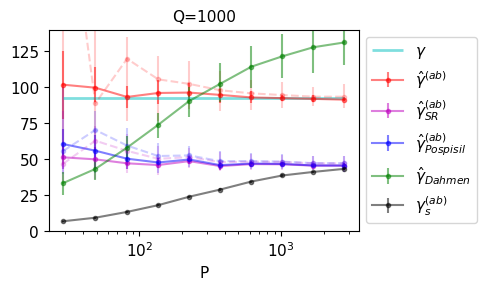

In [83]:

plt.rcParams.update({'font.size': 11})

BiasCorrect=False

fig,ax=plt.subplots(1,1,figsize=(5,3))
#ax.plot(Ps,gims,c='k',label='theory')

xoi=Ps
qoi=GTR

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}$')#, fmt='o')


xoi=Ps
qoi=GTR2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{SR}$')#, fmt='o')

xoi=Ps
qoi=GTR3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}^{(ab)}_{Pospisil}$')#, fmt='o')


xoi=Ps
qoi=GOS

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='r',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS2

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='m',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS3

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='b',marker='o',ls='--',alpha=0.2,ms=3)#, fmt='o')

xoi=Ps
qoi=GOS4

yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='g',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\hat{\gamma}_{Dahmen}$')#, fmt='o')




xoi=Ps
qoi=GS
yval=np.array([np.mean(qoiv) for qoiv in qoi])
lower_error=np.array([np.quantile(qoiv,q=0.25) for qoiv in qoi])
upper_error=np.array([np.quantile(qoiv,q=0.75) for qoiv in qoi])
asymmetric_error = re([(yval-lower_error), (upper_error-yval)])
ax.errorbar(xoi, yval, yerr=asymmetric_error,c='k',marker='o',ls='-',alpha=0.5,ms=3,label=r'$\gamma_s^{(ab)}$')#, fmt='o')

ax.hlines(GTv,np.min(xoi),np.max(xoi),color='c',label=r'$\gamma$',lw=2,alpha=0.5)

ax.set_xlabel('P')
ax.legend(fontsize=11)

ax.set_title('Q={}'.format(Q),fontsize=11)
ax.set_ylim([0,140])

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


plt.tight_layout()

fig.savefig('St_vary_P_shuffle_Q_{}_comp.pdf'.format(Q),format='pdf', bbox_inches = "tight")
            
ax.set_xscale('log')

fig.savefig('St_vary_P_shuffle_Q_{}_comp_log.pdf'.format(Q),format='pdf', bbox_inches = "tight")


# Power law fitting

In [58]:
def getSecond(Xs1,Xs2,M=jnp.inf,F=jnp.inf):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    
    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    Pr=P/M
    Qr=Q/F
    
    #if False:
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.mean(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=1)))
    Term3=-(1-Qhr)/Q * jnp.mean(jnp.square(jnp.mean(Xs1*Xs2,axis=0)))
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.mean(jnp.power(Xs1*Xs2,2))
        
    v =  Term2 + Term3 + Term4
    
    #nsTrKs = jnp.square(jnp.mean(Xs1*Xs2))
    
    # if M and F are infinite, or even if M and F are finite:
    denom =  (nTrKs_min2 +v)
    #numer =  (nsTrKs +v)
    # There are some scaling differences, but all that matters is numer/denom, which cancels out the scaling factors.
    
    denom=denom*P/(P-1)
    return denom


def getSecond_K(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    Kc = jnp.matmul(Xs1,Xs2.T)/Q
    return 2*jnp.trace(jnp.matmul(jnp.triu(Kc, 1),Kc))/(P*(P-1))
        

def compute_A(P, Q, Phi):
    return jnp.mean(Phi**6)
def compute_B(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=1) * jnp.mean(Phi**4, axis=1))
def compute_C(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=1)**3)
def compute_D(P, Q, Phi):
    one=jnp.mean(Phi**2,axis=1)
    sec=(jnp.matmul(Phi,Phi.T)/Q)**2
    return jnp.mean(one[:,None]*sec)
def compute_bar_B(P, Q, Phi):
    return jnp.mean(np.mean(Phi**2, axis=0) * jnp.mean(Phi**4, axis=0))
def compute_bar_C(P, Q, Phi):
    return jnp.mean(jnp.mean(Phi**2, axis=0)**3)
def compute_bar_D(P, Q, Phi):
    one=jnp.mean(Phi**2,axis=0)
    sec=(jnp.matmul(Phi.T,Phi)/P)**2
    return jnp.mean(one[:,None]*sec)
def compute_E(P, Q, Phi):
    return jnp.mean(jnp.matmul(Phi**3,Phi.T)/Q * jnp.matmul(Phi,Phi.T)/Q)
def compute_F(P, Q, Phi):
    return  jnp.mean(jnp.mean(Phi**2,axis=1)[:,None] * jnp.matmul(Phi**2,Phi.T**2)/Q)
def compute_G_prime(P, Q, K_Q):
    return jnp.trace(jnp.linalg.matrix_power(K_Q/P,3))
def getThird(Phi):
    P=np.shape(Phi)[0]
    Q=np.shape(Phi)[1]
    A = compute_A(P, Q, Phi)
    B = compute_B(P, Q, Phi)
    C = compute_C(P, Q, Phi)
    D = compute_D(P, Q, Phi)
    bar_B = compute_bar_B(P, Q, Phi)
    bar_C = compute_bar_C(P, Q, Phi)
    bar_D = compute_bar_D(P, Q, Phi)
    E = compute_E(P, Q, Phi)
    F = compute_F(P, Q, Phi)
    K_Q = jnp.matmul(Phi, Phi.T)/Q
    G_prime = compute_G_prime(P, Q, K_Q)
    
    return G_prime, D, bar_D, C, bar_C, B, bar_B, E, F, A


def getThird_K(Xs1,Xs2):
    P=jnp.shape(Xs1)[0]
    Q=jnp.shape(Xs1)[1]
    Kc = jnp.matmul(Xs1,Xs2.T)/Q
    return 6*jnp.trace(jnp.matmul(jnp.linalg.matrix_power(jnp.triu(Kc, 1),2),Kc))/P/(P-1)/(P-2)


    
Theta1=sresp[0]#[:P,:][:,:Q]
Theta2=sresp[1]#[:P,:][:,:Q]


second=getSecond(Theta1,Theta2)
second_k=getSecond_K(Theta1,Theta2)
#third=getThird(Theta1)

P=np.shape(Theta1)[0]
Q=np.shape(Theta1)[1]

    

third_k=getThird_K(Theta1,Theta2)

print(second)
print(second_k)
print(third)
print(third_k)


0.0050244024
0.00560546
0.00208032
0.0001103726


In [61]:
key = random.PRNGKey(1000)

numit=20
ths=[]
for i in range(numit):
    print(i)
    key_A, key = random.split(key)

    pc=int(P/2)
    random_indicesP = random.choice(key_A,P,shape=(pc,),replace=False)# * sigma
    ThetaM=np.copy(Theta1)
    ThetaM[random_indicesP,:]=Theta2[random_indicesP,:]

    G_prime, D, bar_D, C, bar_C, B, bar_B, E, F, A = getThird(ThetaM)
    G = (P/(P-1)*P/(P-2)* Q/(Q-1)*Q/(Q-2) * G_prime)+(
        - 3* P * Q * (Q * D + P * bar_D)
            + 2 * (Q**2 * C + P**2 * bar_C)
            - 6 * (Q * B + P * bar_B)
            + 6 * P * Q * E
            + 3 * P * Q * F
            + 4 * A )/(P-1)/(P-2)/(Q-1)/(Q-2)
    ths.append(G)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


In [67]:
third=np.mean(ths)
print(third)

first=np.mean(Theta1*Theta2)
print(first)

0.0022180001
0.683509290314664


In [111]:
from scipy.special import zeta

def Hsum(alpha,H):
    n=np.arange(H)+1
    return np.sum(1/np.power(n,alpha))

def bplM(alpha,beta,H,scale):
    
    r=np.power(H,alpha-beta)
    fm = Hsum(beta,H) + r*(zeta(alpha)-Hsum(alpha,H)) 

    rp=np.square(r)
    sm = Hsum(2*beta,H) + rp*(zeta(2*alpha)-Hsum(2*alpha,H))
    
    rt=r**3
    tm = Hsum(3*beta,H) + rt*(zeta(3*alpha)-Hsum(3*alpha,H))
    
    return fm*scale, sm*scale**2, tm*scale**3

scale=1
alphas=np.linspace(1.01,4,10)
betas=np.linspace(0.5,4,11)
Hs=np.linspace(3,20,12).astype(int)

A=np.zeros((np.shape(alphas)[0],np.shape(betas)[0],np.shape(Hs)[0]))
for i,alpha in enumerate(alphas):
    for j,beta in enumerate(betas):
        for k,H in enumerate(Hs):
            fm,sm,tm=bplM(alpha,beta,H,scale)
            A[i,j,k] = (fm-first)**2 + (sm-second)**2 + (tm-third)**2
        

In [117]:
tm

1.000246086553308

Text(0, 0.5, 'alphas')

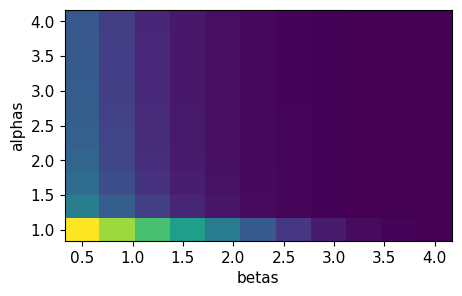

In [112]:
fig,ax=plt.subplots(1,1,figsize=(5,3))
ax.pcolor(betas,alphas,np.log10(A[:,:,5]))
ax.set_xlabel('betas')
ax.set_ylabel('alphas')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import zeta

def Hsum(alpha,H):
    n=np.arange(H)+1
    return np.sum(1/np.power(n,alpha))

def getBPdim(alpha,beta,H):
    r=np.power(H,alpha-beta)
    h = ( Hsum(beta,H) + r*(zeta(alpha)-Hsum(alpha,H)) )**2

    rp=np.square(r)
    g = Hsum(2*beta,H) + rp*(zeta(2*alpha)-Hsum(2*alpha,H))
    return h/g


alpha=1.23
dimval=getBPdim(alpha,0.5,10)


print(dimval)
